# Plot IIRS data for landing sites

Work in progress.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import iirspy.utils as utils
from iirspy import L1

warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in log")

In [2]:
data_dir = Path("~/data/moon/ch2/iirs/").expanduser().as_posix()
data = "landing_sites_iirs.csv"
df = pd.read_csv(data)

# add landing_site_imageID key
df["key"] = df.apply(lambda row: f"{row['LandingSite'].replace(' ', '_')}_{row['ImageID']}", axis=1)

imgs_targeted = {}
imgs_long = {}
for k, im, site, lon, lat in df[["key", "ImageID", "LandingSite", "Lon", "Lat"]].values[:-1]:
    print(k)
    imgs_targeted[k] = L1(im, data_dir, lonlatextent=(None, None, lat - 0.5, lat + 0.5))
    imgs_long[k] = L1(im, data_dir, lonlatextent=(None, None, lat - 5, lat + 5))

Apollo_12_ch2_iir_nci_20211221T0324126144_d_img_hw1
Apollo_16_ch2_iir_nci_20210720T2333026105_d_img_d32
Apollo_17_ch2_iir_nci_20210719T1954073057_d_img_hw1
Luna_16_ch2_iir_nci_20210121T0800523007_d_img_d32
Luna_20_ch2_iir_nci_20210121T0800523007_d_img_d32
Luna_24_ch2_iir_nci_20240520T1759268266_d_img_d18
Chang'e_5_ch2_iir_nci_20220716T0450278161_d_img_hw1
Chang'e_6_ch2_iir_nci_20240605T2337002684_d_img_d18
Chang'e_6_ch2_iir_nci_20240606T0133308304_d_img_d18


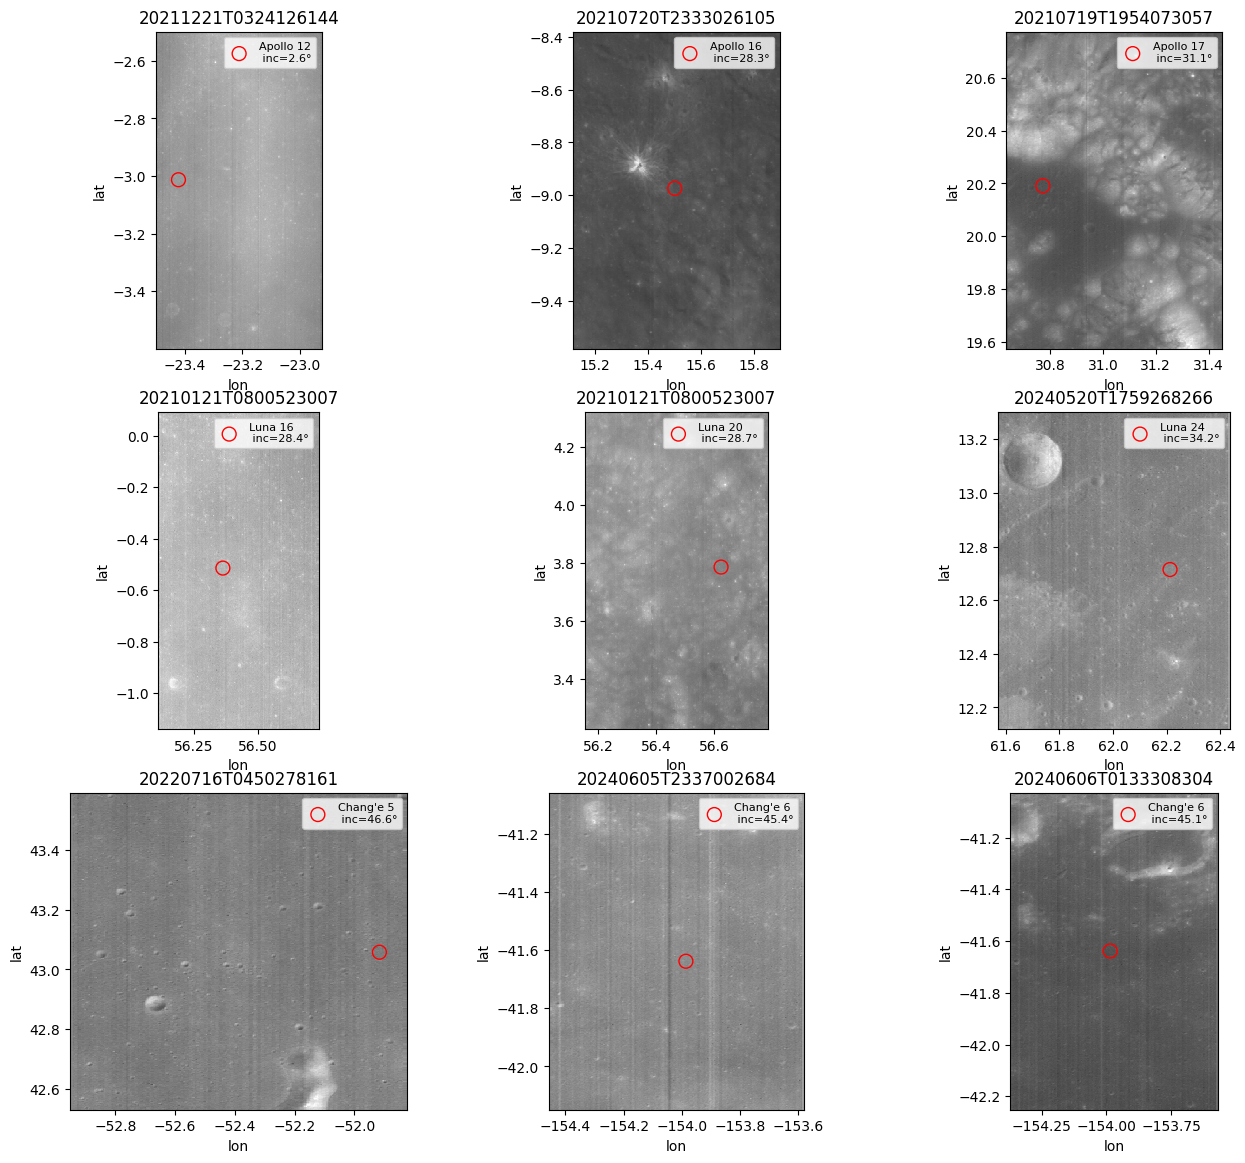

In [3]:
imgs = imgs_targeted
fig, axs = plt.subplots(3, 3, figsize=(16, 14))
for i, (k, l1) in enumerate(imgs.items()):
    ax = axs.flatten()[i]
    l1.plot(ax=ax, cmap="gray", add_colorbar=False)
    # Plot the landing site as a red circle on the image
    row = df[df["key"] == k].iloc[0]
    ax.scatter(
        float(row["Lon"]),
        row["Lat"],
        facecolor="none",
        edgecolor="red",
        s=100,
        marker="o",
        label=f'{row["LandingSite"]}\n inc={l1.img.solar_inc.mean():.1f}°',
    )
    ax.legend(loc="upper right", fontsize=8)
# Hide unused axes if there are any
for j in range(len(imgs), axs.size):
    axs.flatten()[j].axis("off")

Text(0.5, 1.0, 'Median spectra within 0.05 degrees')

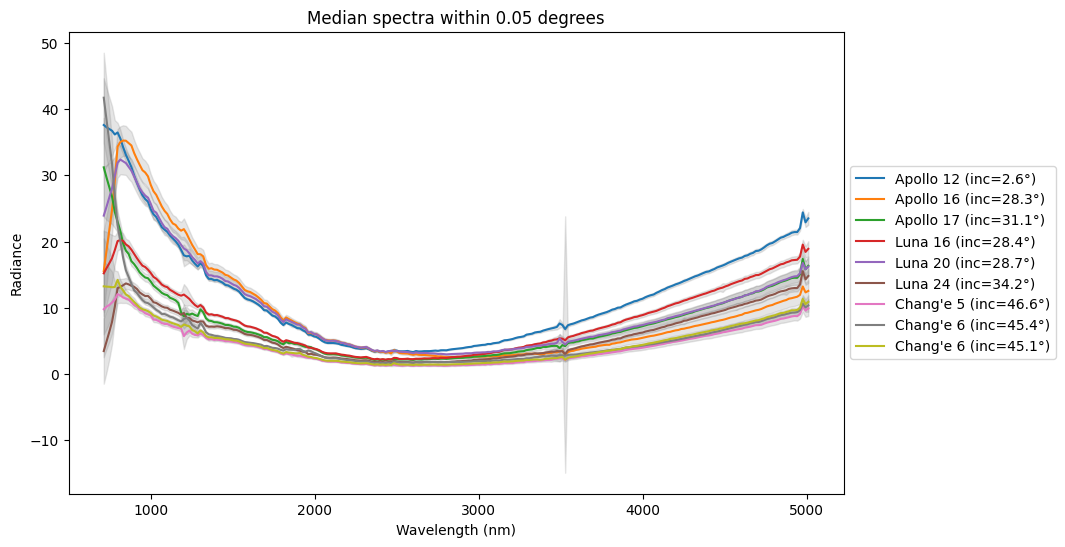

In [4]:
# Plot median spectrum for each landing site
fig, ax = plt.subplots(figsize=(10, 6))
radius = 0.05  # degrees


def get_xyrange_for_site(l1, site_lat, site_lon, delta=0.05):
    # Extract spectrum within +/- delta degrees
    lonmin = site_lon - delta
    lonmax = site_lon + delta
    latmin = site_lat - delta
    latmax = site_lat + delta
    # Get mask for points within lat/lon bounds
    mask = (l1.img.lon >= lonmin) & (l1.img.lon <= lonmax) & (l1.img.lat >= latmin) & (l1.img.lat <= latmax)

    # Get x and y indices where mask is True
    x_indices, y_indices = np.where(mask)

    # Get x and y ranges
    xrange = (l1.img.x[x_indices.min()], l1.img.x[x_indices.max()])
    yrange = (l1.img.y[y_indices.min()], l1.img.y[y_indices.max()])
    return xrange, yrange


for i, (k, l1) in enumerate(imgs.items()):
    # Get landing site coordinates
    row = df[df["key"] == k].iloc[0]
    site_lat = float(row["Lat"])
    site_lon = float(row["Lon"])
    xrange, yrange = get_xyrange_for_site(l1, site_lat, site_lon, delta=radius)
    spectrum = l1.plot_spectra(
        xrange=xrange,
        yrange=yrange,
        ax=ax,
        label=f"{row['LandingSite']} (inc={l1.img.solar_inc.mean():.1f}°)",
    )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel("Radiance")
ax.set_xlabel("Wavelength (nm)")
ax.set_title(f"Median spectra within {radius} degrees")

Text(0.5, 1.0, 'Nearest Pixel Spectra')

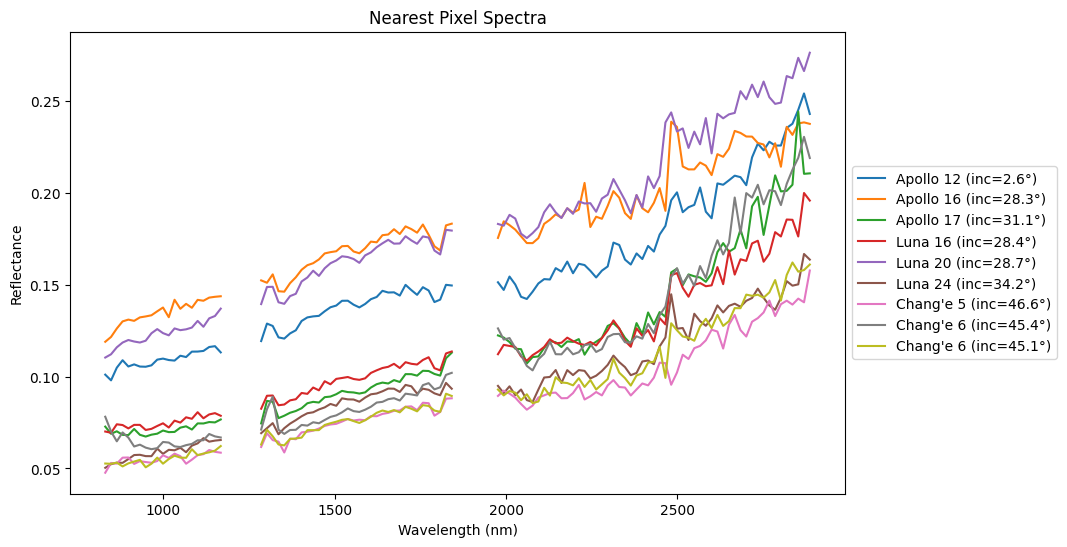

In [5]:
# Plot reflectance spectra
refl = {}
for i, (k, l1) in enumerate(imgs.items()):
    refl[k] = l1.calibrate(thermal_corr="verma").img.compute()

# Plot nearest pixel spectrum for each landing site
fig, ax = plt.subplots(figsize=(10, 6))
for i, (k, img) in enumerate(refl.items()):
    row = df[df["key"] == k].iloc[0]

    xrange, yrange = get_xyrange_for_site(imgs[k], float(row["Lat"]), float(row["Lon"]), delta=0.05)
    cx = (xrange[0] + xrange[1]) / 2
    cy = (yrange[0] + yrange[1]) / 2
    img.where(~img.band.isin((*utils.OSF, *utils.INVALID))).isel(band=slice(7, 130)).sel(
        x=cx, y=cy, method="nearest"
    ).plot(
        x="wl",
        ax=ax,
        label=f"{row['LandingSite']} (inc={imgs[k].img.solar_inc.mean():.1f}°)",
    )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel("Reflectance")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Nearest Pixel Spectra")

Text(0.5, 1.0, 'Median spectra within 0.05 degrees')

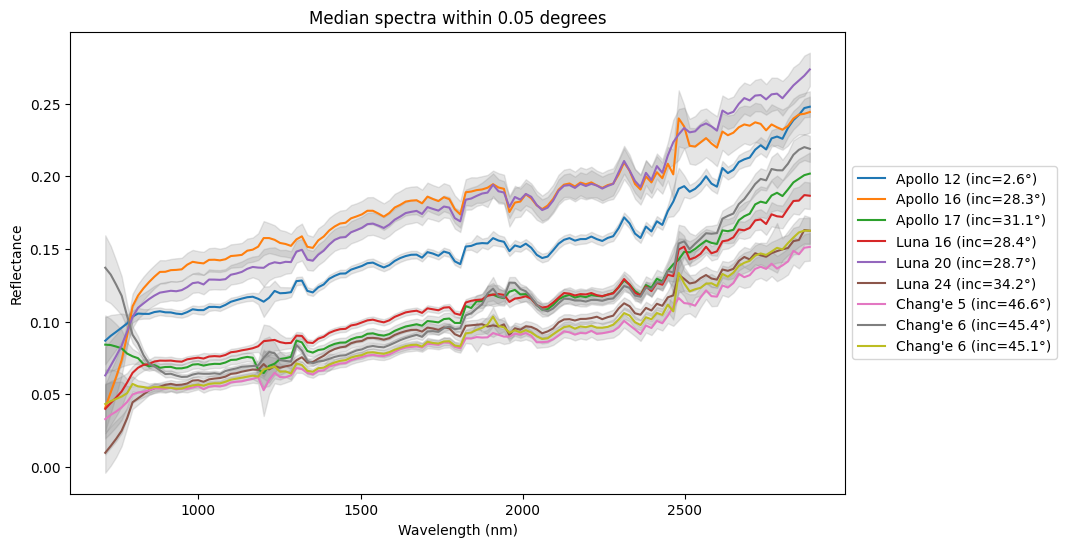

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, (k, img) in enumerate(refl.items()):
    row = df[df["key"] == k].iloc[0]

    xrange, yrange = get_xyrange_for_site(imgs[k], float(row["Lat"]), float(row["Lon"]), delta=0.05)
    spectrum = utils.plot_spectra_with_sigma(
        img.isel(band=slice(0, 130)).sel(x=slice(xrange[0], xrange[1]), y=slice(yrange[0], yrange[1])),
        ax=ax,
        label=f"{row['LandingSite']} (inc={imgs[k].img.solar_inc.mean():.1f}°)",
    )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel("Reflectance")
ax.set_xlabel("Wavelength (nm)")
ax.set_title(f"Median spectra within {radius} degrees")